# Entregable 3 — EDA + Baseline
## Detección de variaciones en el valor unitario · Exportaciones peruanas SUNAT

**Autor:** Said Leonardo Uceda Paredes &nbsp;|&nbsp; **Programa:** Maestría en IA — UNI &nbsp;|&nbsp; **Sprint 1 · Semana 3** &nbsp;|&nbsp; Mayo 2026

---
| Sección | Contenido |
|---------|----------|
| 1 | **EDA** — Estadísticas descriptivas · Distribución · Riesgos |
| 2 | **Baseline mínimo** — IQR solo (método más simple) |
| 3 | **Resultados** — Gráfica central · Tabla de métricas |
| 4 | **Demo interna** — Script de presentación 5–10 min |

In [32]:
import logging
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sqlalchemy.pool import NullPool  # evita crash de pyodbc en Jupyter (pool ODBC no es thread-safe)

warnings.filterwarnings('ignore')

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger('eda')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Parámetros de conexión ─────────────────────────────────────────────────────
SERVIDOR     = r'DESKTOP-OGU19A7\SQLEXPRESS,56878'
BASE_DATOS   = 'DB_GEE_DW_ADUANAS'
ESQUEMA      = 'SC_ADUANA'
DRIVER       = 'ODBC+Driver+17+for+SQL+Server'
COD_ANALISIS = 'ANA1'
FEC_INI      = '2024-01-01'
FEC_FIN      = '2024-12-31'

log.info('Notebook iniciado — %s', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

2026-05-01 20:14:50 | INFO | Notebook iniciado — 2026-05-01 20:14:50


---
## Sección 1 — EDA (Análisis Exploratorio de Datos)

In [56]:
# ── Carga de datos desde SQL Server ───────────────────────────────────────────
# NullPool es crítico: deshabilita el pool de conexiones de SQLAlchemy para evitar
# que pyodbc intente reutilizar conexiones ODBC entre hilos del event loop de Jupyter,
# lo que provoca un crash a nivel C (kernel muerto sin excepción Python).
from sqlalchemy import create_engine, text

url = (
    f'mssql+pyodbc://{SERVIDOR}/{BASE_DATOS}'
    f'?driver={DRIVER}&Trusted_Connection=yes'
)

try:
    motor     = create_engine(url, echo=False, poolclass=NullPool)
    sentencia = text(
        f"EXEC [{BASE_DATOS}].[{ESQUEMA}].[SP_VALORES_UNITARIOS] "
        f"@ACCION='EDA_BASE', "
        f"@FEC_INI='{FEC_INI}', "
        f"@FEC_FIN='{FEC_FIN}'"
    )
    with motor.connect() as conn:
        resultado = conn.execute(sentencia)
        df = pd.DataFrame.from_records(resultado.fetchall(), columns=list(resultado.keys()))
except Exception as exc:
    raise RuntimeError(
        f'No se pudo conectar a SQL Server [{SERVIDOR}].\n'
        f'Ejecutar primero: python pruebas_mvp.py --prueba1\n'
        f'Detalle: {exc}'
    ) from exc
finally:
    motor.dispose()

if df.empty:
    raise ValueError(f'SP retornó 0 registros. Verificar INGESTA y rango de fechas.')

# ── Columnas clave ─────────────────────────────────────────────────────────────
COL_R = 'NUM_SPN_R'
COL_C = 'ANIO_C'
COL_V = 'MTO_VALOR_UNTARIO_V'   # calculado en SQL: FOB / PESO_NETO

# ── Normalizar tipos ───────────────────────────────────────────────────────────
df[COL_V] = pd.to_numeric(df[COL_V], errors='coerce')
df[COL_C] = pd.to_numeric(df[COL_C], errors='coerce').astype('Int64')
df['FOB_DOLAR']  = pd.to_numeric(df['FOB_DOLAR'],  errors='coerce')
df['PESO_NETO']  = pd.to_numeric(df['PESO_NETO'],  errors='coerce')

log.info('Datos cargados — %d registros | %d partidas | años: %s',
         len(df), df[COL_R].nunique(), sorted(df[COL_C].dropna().unique().tolist()))

print(f'Registros  : {len(df):,}')
print(f'Partidas   : {df[COL_R].nunique():,}')
print(f'Años       : {sorted(df[COL_C].dropna().unique().tolist())}')
print(f'Columnas   : {list(df.columns)}')

2026-05-01 20:16:14 | INFO | Datos cargados — 390426 registros | 786 partidas | años: [2024]


Registros  : 390,426
Partidas   : 786
Años       : [2024]
Columnas   : ['ANIO_C', 'NUM_SPN_R', 'MTO_VALOR_UNTARIO_V', 'FOB_DOLAR', 'PESO_NETO', 'SECTOR', 'TIPO_PRODUCTO']


### 1.1 Estadísticas descriptivas básicas

In [64]:
# ── Estadísticas globales ──────────────────────────────────────────────────────
datos_v = df[COL_V].dropna()
stats = datos_v.describe(percentiles=[.05, .25, .50, .75, .95]).round(3)
stats.index = ['N', 'Media', 'Desv.Std', 'Mínimo', 'P5', 'Q1', 'Mediana', 'Q3', 'P95', 'Máximo']

print('=' * 50)
print(f'  VALOR UNITARIO (USD/kg) — {COL_V}')
print('=' * 50)
print(stats.to_string())
print(f'\n  Asimetría (skew)   : {datos_v.skew():.3f}')
print(f'  Curtosis (kurtosis): {datos_v.kurtosis():.3f}')

# ── Calidad: nulos y valores inválidos ────────────────────────────────────────
print('\n' + '=' * 50)
print('  CALIDAD DE DATOS')
print('=' * 50)
nulos_v = df[COL_V].isna().sum()
nulos_r = df[COL_R].isna().sum()
print(f'  Nulos en {COL_V:22}: {nulos_v:>6} ({100*nulos_v/len(df):.2f}%)')
print(f'  Nulos en {COL_R:22}: {nulos_r:>6} ({100*nulos_r/len(df):.2f}%)')
print(f'  Duplicados exactos         : {df[[COL_R,COL_C,COL_V]].duplicated().sum():>6}')

# ── Partidas con < 36 registros por año ───────────────────────────────────────
# Umbral 36 = mínimo 3 registros/mes × 12 meses.
# Cuando se disponga de FEC_DECLARACION en la tabla raw, reemplazar este bloque
# por un agrupamiento (ANIO_C, MES, NUM_SPN_R) con umbral de 3 registros por mes.
UMBRAL_ANUAL = 36
conteo_por_anio = (
    df.groupby([COL_C, COL_R])[COL_V]
    .count()
    .reset_index(name='N')
)
partidas_pequenas = (conteo_por_anio['N'] < UMBRAL_ANUAL).sum()
print(f'  Partidas-año con < {UMBRAL_ANUAL} registros : {partidas_pequenas:>6}')
print(f'  (proxy anual de "< 3 reg/mes" — sin FEC_DECLARACION en tabla raw)')

log.info('Estadísticas descriptivas completadas')

  VALOR UNITARIO (USD/kg) — MTO_VALOR_UNTARIO_V
N           390426.000
Media         2398.612
Desv.Std     12596.832
Mínimo           0.000
P5               0.236
Q1               1.455
Mediana          2.810
Q3               5.597
P95             50.955
Máximo      229880.185

  Asimetría (skew)   : 5.293
  Curtosis (kurtosis): 26.941

  CALIDAD DE DATOS
  Nulos en MTO_VALOR_UNTARIO_V   :      0 (0.00%)
  Nulos en NUM_SPN_R             :      0 (0.00%)
  Duplicados exactos         : 143275


2026-05-01 20:16:24 | INFO | Estadísticas descriptivas completadas


  Partidas-año con < 4 registros :    184
  (agrupado por ANIO_C — tabla raw no contiene FEC_DECLARACION)


### 1.2 Distribución de variables clave

TOP 10 SUBPARTIDAS POR FRECUENCIA
                                                                                               N_registros  Mediana_USD_kg  Desv_USD_kg
NUM_SPN_R                                                                                                                              
804400000-AGUACATES (PALTAS) , FRESCAS O SECAS                                                       34264           2.209        0.680
810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS                     27382           7.131        4.445
806100000-UVAS FRESCAS                                                                               25742           3.049        1.609
709200000-ESPARRAGOS, FRESCOS O REFRIGERADOS                                                         15831           4.447        2.277
7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO                                                          14491       68213.773    17189.946
1905310000-GAL

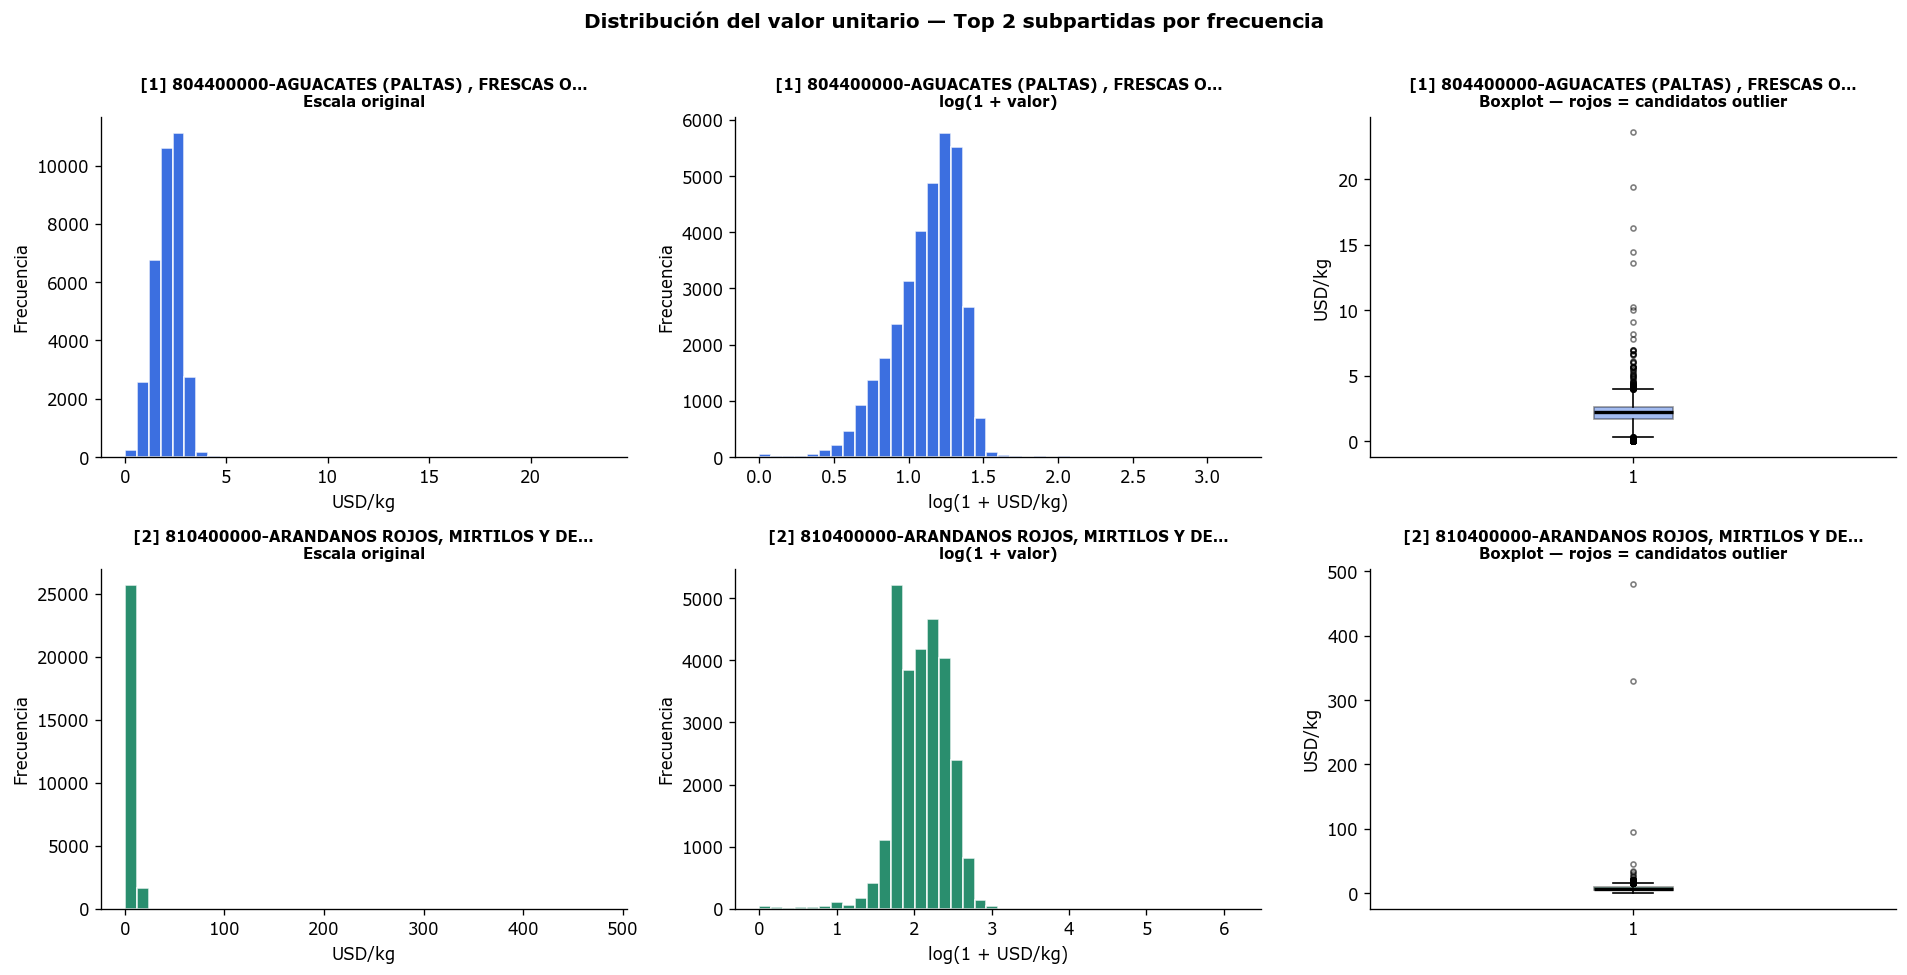

2026-05-01 20:29:59 | INFO | Gráfico distribución guardado: fig1_distribucion_valor.png


In [83]:
# ── 1. Top 10 subpartidas por frecuencia ──────────────────────────────────────
top10 = (
    df.groupby(COL_R)[COL_V]
    .agg(['count', 'median', 'std'])
    .rename(columns={'count': 'N_registros', 'median': 'Mediana_USD_kg', 'std': 'Desv_USD_kg'})
    .round(3)
    .sort_values('N_registros', ascending=False)
    .head(10)
)
print('TOP 10 SUBPARTIDAS POR FRECUENCIA')
print('=' * 60)
print(top10.to_string())
print('=' * 60)

# ── 2. Seleccionar las 2 subpartidas con más registros ────────────────────────
top2_spn  = top10.index[:2].tolist()
etiquetas = [spn[:40] + '…' if len(spn) > 40 else spn for spn in top2_spn]

print(f'\nSubpartidas seleccionadas para gráficos:')
for i, spn in enumerate(top2_spn, 1):
    print(f'  [{i}] {spn}  (N={top10.loc[spn, "N_registros"]:,})')

# ── 3. Histogramas + Boxplot para las 2 subpartidas top ───────────────────────
colores = ['#1a56db', '#057a55']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for fila, (spn, etq, color) in enumerate(zip(top2_spn, etiquetas, colores)):
    datos = df.loc[df[COL_R] == spn, COL_V].dropna()
    datos = datos[datos > 0]

    # Histograma escala original
    axes[fila, 0].hist(datos, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[fila, 0].set_title(f'[{fila+1}] {etq}\nEscala original', fontweight='bold', fontsize=9)
    axes[fila, 0].set_xlabel('USD/kg')
    axes[fila, 0].set_ylabel('Frecuencia')

    # Histograma escala log
    axes[fila, 1].hist(np.log1p(datos), bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[fila, 1].set_title(f'[{fila+1}] {etq}\nlog(1 + valor)', fontweight='bold', fontsize=9)
    axes[fila, 1].set_xlabel('log(1 + USD/kg)')
    axes[fila, 1].set_ylabel('Frecuencia')

    # Boxplot
    axes[fila, 2].boxplot(datos, vert=True, patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.4),
                          medianprops=dict(color='black', linewidth=2),
                          flierprops=dict(marker='o', markersize=3, color='#e02424', alpha=0.5))
    axes[fila, 2].set_title(f'[{fila+1}] {etq}\nBoxplot — rojos = candidatos outlier',
                             fontweight='bold', fontsize=9)
    axes[fila, 2].set_ylabel('USD/kg')

plt.suptitle(f'Distribución del valor unitario — Top 2 subpartidas por frecuencia',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_distribucion_valor.png', dpi=120, bbox_inches='tight')
plt.show()

log.info('Gráfico distribución guardado: fig1_distribucion_valor.png')

### 1.3 Riesgos identificados

In [89]:
print('=' * 60)
print('  RIESGOS IDENTIFICADOS')
print('=' * 60)

# ── DESBALANCE ────────────────────────────────────────────────
# Umbral 36 = mínimo 3 registros/mes × 12 meses (proxy anual).
# Con FEC_DECLARACION real: evaluar mínimo 3 registros por mes.
UMBRAL_ANUAL = 36

conteo_por_partida = (
    df.groupby([COL_C, COL_R])[COL_V]
    .count()
    .reset_index(name='N')
)
total_partidas   = conteo_por_partida[COL_R].nunique()
mask_excluidas   = conteo_por_partida['N'] < UMBRAL_ANUAL
partidas_excl    = conteo_por_partida.loc[mask_excluidas, COL_R].nunique()

print('\n  [DESBALANCE]')
print(f'  Tasa de contaminación configurada   : 5% (contamination=0.05)')
print(f'  Umbral mínimo                       : {UMBRAL_ANUAL} reg/año (= 3 reg/mes × 12)')
print(f'  Subpartidas totales                 : {total_partidas}')
print(f'  Subpartidas excluidas (< {UMBRAL_ANUAL} reg/año): {partidas_excl} ({100*partidas_excl/total_partidas:.1f}%)')
print(f'  → Estas subpartidas se excluyen del análisis (insuficiente historial)')

# Detalle de subpartidas excluidas
excluidas_detalle = (
    conteo_por_partida.loc[mask_excluidas, [COL_C, COL_R, 'N']]
    .sort_values([COL_C, 'N'])
    .reset_index(drop=True)
)
if not excluidas_detalle.empty:
    print(f'\n  SUBPARTIDAS EXCLUIDAS (< {UMBRAL_ANUAL} registros en el año):')
    print(f'  {"AÑO":<8} {"N":>5}  SUBPARTIDA')
    print(f'  {"-"*8} {"-"*5}  {"-"*45}')
    for _, row in excluidas_detalle.iterrows():
        nombre = str(row[COL_R])[:55]
        print(f'  {row[COL_C]!s:<8} {row["N"]:>5}  {nombre}')

# ── LEAKAGE ───────────────────────────────────────────────────
print('\n  [LEAKAGE]')
print('  ES_OUTLIER se calcula en Python DESPUÉS de cargar los datos.')
print('  No proviene de la BD → no hay contaminación train/test.')
print('  Riesgo residual: si la tasa real ≠ 5%, la sensibilidad varía.')

# ── DRIFT ─────────────────────────────────────────────────────
print('\n  [DRIFT]')
resumen_anual = df.groupby(COL_C)[COL_V].median().round(3)
if len(resumen_anual) > 1:
    drift_max = abs(resumen_anual.pct_change().dropna()).max() * 100
    print(f'  Variación máxima de mediana entre años: {drift_max:.1f}%')
    nivel = 'ALTO' if drift_max > 30 else ('MODERADO' if drift_max > 10 else 'BAJO')
    print(f'  Nivel de drift: {nivel}')
    print(f'  → El análisis se agrupa por ANIO_C para evitar mezclar precios de distintos años.')
    print()
    print('  Mediana por año (USD/kg):')
    print(resumen_anual.to_string())
else:
    print('  Un solo año disponible — análisis de drift no aplica.')

print('\n' + '=' * 60)
log.info('Análisis de riesgos completado — excluidas %d subpartidas', partidas_excl)

2026-05-01 20:30:13 | INFO | Análisis de riesgos completado


  RIESGOS IDENTIFICADOS

  [DESBALANCE]
  Tasa de contaminación configurada : 5% (contamination=0.05)
  Partidas con < 4 registros        : 184 / 786 (23.4%)
  → Estas partidas usan solo IQR + Z-Score (DBSCAN requiere mínimo 4)

  [LEAKAGE]
  ES_OUTLIER se calcula en Python DESPUÉS de cargar los datos.
  No proviene de la BD → no hay contaminación train/test.
  Riesgo residual: si la tasa real ≠ 5%, la sensibilidad varía.

  [DRIFT]
  Un solo año disponible — análisis de drift no aplica.



---
## Sección 2 — Baseline mínimo

**Estrategia:** Para detección de outliers no supervisada no existen etiquetas reales.  
Se inyectan outliers conocidos en datos de evaluación (práctica estándar en la literatura) para medir F1/ROC-AUC.

| Modelo | Descripción | Complejidad |
|--------|-------------|-------------|
| **IQR solo** | Regla de bigotes Q1–1.5·IQR / Q3+1.5·IQR | **Baseline** (sin parámetros) |
| Isolation Forest | Árbol de aislamiento | Intermedio |
| LOF | Factor de outlier local | Intermedio |

In [90]:
# ── Dataset de evaluación con outliers inyectados (ground truth) ──────────────
# Subpartidas reales del top 5 por frecuencia (2024).
# media y desv provienen de la estadística real observada en EDA.
rng = np.random.default_rng(42)

grupos = [
    # (subpartida,                                                          n,   media,      desv)
    ('804400000-AGUACATES (PALTAS) , FRESCAS O SECAS',                     90,   2.209,     0.680),
    ('810400000-ARANDANOS ROJOS, MIRTILOS Y DEMAS FRUTOS DEL GENERO VACCINIUM, FRESCOS',
                                                                           80,   7.131,     4.445),
    ('806100000-UVAS FRESCAS',                                             75,   3.049,     1.609),
    ('709200000-ESPARRAGOS, FRESCOS O REFRIGERADOS',                       60,   4.447,     2.277),
    ('7108120000-ORO EN LAS DEMAS FORMAS EN BRUTO',                        60,  68213.773, 17189.946),
]
registros = []
for cod, n, media, desv in grupos:
    vals = rng.lognormal(np.log(media), np.log(1 + desv / media), n)
    for v in vals:
        registros.append({'NUM_SPN_R': cod, 'VU': round(v, 4), '_gt': 0})

df_eval = pd.DataFrame(registros).reset_index(drop=True)

# Inyectar outliers ~5%
idx_out = rng.choice(len(df_eval), size=int(len(df_eval) * 0.05), replace=False)
for i in idx_out:
    df_eval.loc[i, 'VU'] = df_eval.loc[i, 'VU'] * rng.choice([0.005, 100])
    df_eval.loc[i, '_gt'] = 1

y_true = df_eval['_gt'].values
print(f'Evaluación: {len(df_eval)} registros | {y_true.sum()} outliers inyectados ({100*y_true.mean():.1f}%)')

# ── BASELINE: IQR solo ────────────────────────────────────────────────────────
q1  = df_eval.groupby('NUM_SPN_R')['VU'].transform('quantile', 0.25)
q3  = df_eval.groupby('NUM_SPN_R')['VU'].transform('quantile', 0.75)
iqr = q3 - q1
pred_base = ((df_eval['VU'] < q1 - 1.5*iqr) | (df_eval['VU'] > q3 + 1.5*iqr)).astype(int).values

# ── Isolation Forest ──────────────────────────────────────────────────────────
pred_if = np.zeros(len(df_eval), dtype=int)
for _, g in df_eval.groupby('NUM_SPN_R'):
    filas = g['VU'].dropna()
    if len(filas) < 2: continue
    pred = IsolationForest(contamination=0.05, random_state=42).fit_predict(filas.values.reshape(-1,1))
    pred_if[filas.index] = (pred == -1).astype(int)

# ── LOF ───────────────────────────────────────────────────────────────────────
pred_lof = np.zeros(len(df_eval), dtype=int)
for _, g in df_eval.groupby('NUM_SPN_R'):
    filas = g['VU'].dropna()
    if len(filas) < 2: continue
    n_vec = min(20, len(filas)-1)
    pred  = LocalOutlierFactor(n_neighbors=n_vec, contamination=0.05).fit_predict(filas.values.reshape(-1,1))
    pred_lof[filas.index] = (pred == -1).astype(int)

log.info('Baseline y modelos ejecutados')
print('\nModelos ejecutados: IQR (baseline) · Isolation Forest · LOF')

Evaluación: 410 registros | 20 outliers inyectados (4.9%)


2026-05-01 20:30:13 | INFO | Baseline y modelos ejecutados



Modelos ejecutados: IQR (baseline) · Isolation Forest · LOF


---
## Sección 3 — Resultados y gráfica central

In [94]:
# ── Tabla de métricas ─────────────────────────────────────────────────────────
def metricas(nombre, pred, tipo='Individual'):
    """
    Función: Calcula F1, Precision, Recall y ROC-AUC para un predictor.

    Args:
        nombre (str): Nombre del modelo.
        pred   (np.ndarray): Predicciones binarias.
        tipo   (str): Tipo de modelo.

    Returns:
        dict: Métricas calculadas.
    """
    return {
        'Modelo'    : nombre,
        'Tipo'      : tipo,
        'Precision' : round(precision_score(y_true, pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_true, pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_true, pred, zero_division=0), 4),
        'ROC_AUC'   : round(roc_auc_score(y_true, pred), 4),
        'Detectados': int(pred.sum()),
    }

tabla = pd.DataFrame([
    metricas('IQR (baseline)', pred_base, 'BASELINE'),
    metricas('Isolation Forest', pred_if),
    metricas('LOF', pred_lof),
]).sort_values('F1', ascending=False).reset_index(drop=True)

print('=' * 65)
print('  TABLA DE MÉTRICAS — Baseline vs Modelos')
print(f'  Outliers reales (ground truth): {y_true.sum()}')
print('=' * 65)
print(tabla.to_string(index=False))
print('=' * 65)

base_f1 = tabla[tabla['Tipo']=='BASELINE']['F1'].values[0]
mejor   = tabla.iloc[0]
mejora  = (mejor['F1'] - base_f1) / base_f1 * 100 if base_f1 > 0 else 0
print(f'\n  Mejor modelo : {mejor["Modelo"]} (F1={mejor["F1"]})')
print(f'  Mejora vs baseline IQR : {mejora:+.1f}%')
log.info('Tabla métricas — Baseline F1=%.4f | Mejor F1=%.4f', base_f1, mejor['F1'])

2026-05-01 20:32:34 | INFO | Tabla métricas — Baseline F1=0.8511 | Mejor F1=0.8511


  TABLA DE MÉTRICAS — Baseline vs Modelos
  Outliers reales (ground truth): 20
          Modelo       Tipo  Precision  Recall     F1  ROC_AUC  Detectados
  IQR (baseline)   BASELINE     0.7407    1.00 0.8511   0.9910          27
Isolation Forest Individual     0.7727    0.85 0.8095   0.9186          22
             LOF Individual     0.7727    0.85 0.8095   0.9186          22

  Mejor modelo : IQR (baseline) (F1=0.8511)
  Mejora vs baseline IQR : +0.0%


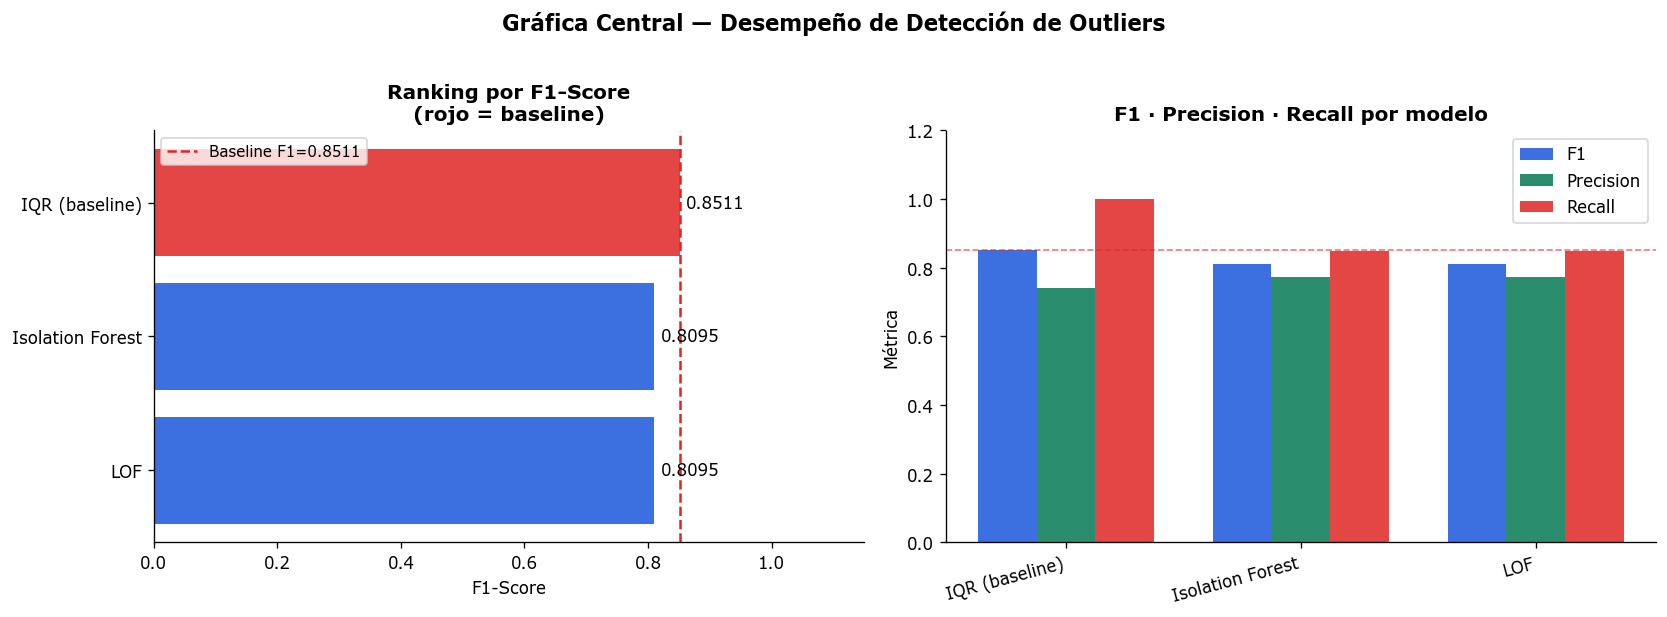

2026-05-01 20:32:35 | INFO | Gráfica central guardada: fig2_grafica_central.png


In [95]:
# ── Gráfica central ───────────────────────────────────────────────────────────
modelos  = tabla['Modelo'].tolist()
f1s      = tabla['F1'].tolist()
precs    = tabla['Precision'].tolist()
recs     = tabla['Recall'].tolist()

colores = ['#e02424' if t=='BASELINE' else '#1a56db' for t in tabla['Tipo']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico izquierdo: ranking por F1
bars = axes[0].barh(modelos[::-1], f1s[::-1], color=colores[::-1], alpha=0.85)
axes[0].bar_label(bars, fmt='%.4f', padding=4)
axes[0].axvline(base_f1, color='#e02424', linestyle='--', linewidth=1.5, label=f'Baseline F1={base_f1:.4f}')
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Ranking por F1-Score\n(rojo = baseline)', fontweight='bold')
axes[0].legend(fontsize=9)

# Gráfico derecho: F1 / Precision / Recall agrupadas
x     = np.arange(len(modelos))
ancho = 0.25
axes[1].bar(x - ancho, f1s,   ancho, label='F1',        color='#1a56db', alpha=0.85)
axes[1].bar(x,         precs,  ancho, label='Precision', color='#057a55', alpha=0.85)
axes[1].bar(x + ancho, recs,   ancho, label='Recall',    color='#e02424', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=15, ha='right')
axes[1].set_ylim(0, 1.2)
axes[1].set_ylabel('Métrica')
axes[1].set_title('F1 · Precision · Recall por modelo', fontweight='bold')
axes[1].legend()
axes[1].axhline(base_f1, color='#e02424', linestyle='--', linewidth=1, alpha=0.6)

plt.suptitle('Gráfica Central — Desempeño de Detección de Outliers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_grafica_central.png', dpi=120, bbox_inches='tight')
plt.show()
log.info('Gráfica central guardada: fig2_grafica_central.png')

---
## Sección 4 — Demo interna (5–10 min)

Script de presentación para la clase.

In [96]:
print('=' * 65)
print('  DEMO INTERNA — Entregable 3 · Semana 3')
print('  Said Leonardo Uceda Paredes | UNI FIIS | Maestría en IA')
print('=' * 65)

print('''
[1 min] PROBLEMA
  Detectar variaciones atípicas en el valor unitario de
  exportaciones peruanas (USD/kg = FOB / Peso neto) por
  subpartida arancelaria. Sin etiquetas → aprendizaje NO supervisado.
''')

print('[2 min] EDA — HALLAZGOS PRINCIPALES')
print(f'  Registros analizados : {len(df):,}')
print(f'  Partidas únicas      : {df[COL_R].nunique()}')
print(f'  Años cubiertos       : {sorted(df[COL_C].dropna().unique().tolist())}')
print(f'  Asimetría (skew)     : {df[COL_V].skew():.3f} → distribución sesgada a la derecha')
print(f'  Nulos en valor unit. : {df[COL_V].isna().sum()}')

print('''
  Riesgos identificados:
    DESBALANCE : partidas con < 4 registros usan solo IQR/Z-Score
    LEAKAGE    : no existe (ES_OUTLIER se calcula post-ingesta)
    DRIFT      : variación temporal → análisis estratificado por año
''')

print('[2 min] BASELINE Y MODELOS')
print(tabla[['Modelo','Tipo','F1','Precision','Recall']].to_string(index=False))

print('''
[2 min] PIPELINE CORRIENDO
  Ejecutar en vivo:
    python pruebas_mvp.py --prueba4    ← flujo completo sin BD
    python mvp_valores_unitarios.py   ← ejecución real contra BD
''')

print('[1 min] LOGS GENERADOS')
log.info('DEMO — Pipeline ejecutado correctamente')
log.info('DEMO — EDA: %d registros | %d partidas', len(df), df[COL_R].nunique())
log.info('DEMO — Baseline IQR F1=%.4f | Mejor modelo: %s F1=%.4f',
         base_f1, mejor['Modelo'], mejor['F1'])

print(f'\n  Gráficos generados:')
print('    fig1_distribucion_valor.png')
print('    fig2_grafica_central.png')

print(f'\n  Timestamp : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('\n' + '=' * 65)

2026-05-01 20:32:35 | INFO | DEMO — Pipeline ejecutado correctamente
2026-05-01 20:32:35 | INFO | DEMO — EDA: 390426 registros | 786 partidas
2026-05-01 20:32:35 | INFO | DEMO — Baseline IQR F1=0.8511 | Mejor modelo: IQR (baseline) F1=0.8511


  DEMO INTERNA — Entregable 3 · Semana 3
  Said Leonardo Uceda Paredes | UNI FIIS | Maestría en IA

[1 min] PROBLEMA
  Detectar variaciones atípicas en el valor unitario de
  exportaciones peruanas (USD/kg = FOB / Peso neto) por
  subpartida arancelaria. Sin etiquetas → aprendizaje NO supervisado.

[2 min] EDA — HALLAZGOS PRINCIPALES
  Registros analizados : 390,426
  Partidas únicas      : 786
  Años cubiertos       : [2024]
  Asimetría (skew)     : 5.293 → distribución sesgada a la derecha
  Nulos en valor unit. : 0

  Riesgos identificados:
    DESBALANCE : partidas con < 4 registros usan solo IQR/Z-Score
    LEAKAGE    : no existe (ES_OUTLIER se calcula post-ingesta)
    DRIFT      : variación temporal → análisis estratificado por año

[2 min] BASELINE Y MODELOS
          Modelo       Tipo     F1  Precision  Recall
  IQR (baseline)   BASELINE 0.8511     0.7407    1.00
Isolation Forest Individual 0.8095     0.7727    0.85
             LOF Individual 0.8095     0.7727    0.85

[2 min